Looking at the total average NPS right now

In [21]:
import pandas as pd

In [22]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [23]:
df = pd.read_parquet("Data/final_data.parquet")

In [24]:

# One row per service_id (Aggregated NPS is identical within a service)
nps_per_service = df.drop_duplicates(subset='service_id')[['service_id', 'Aggregated NPS']]

mean_nps = nps_per_service['Aggregated NPS'].mean()

print(f"Unique service IDs: {len(nps_per_service)}")
print(f"Mean Aggregated NPS across all unique services: {mean_nps:.4f}  ({mean_nps * 100:.2f} on 0-100 scale)")

Unique service IDs: 36511
Mean Aggregated NPS across all unique services: 0.3414  (34.14 on 0-100 scale)


In [25]:
df.head()

,metadata_booking_date,metadata_class_of_service,metadata_class_of_service_code,metadata_coach_number,metadata_compensation_flag,metadata_currency,metadata_delay_code,metadata_delay_at_arrival,metadata_departure_date,metadata_departure_hour,metadata_destination_station,metadata_destination_station_code,metadata_disrup,metadata_origin_station,metadata_origin_station_code,metadata_price,metadata_on_board_the_train_v,metadata_overall_experience_v,metadata_q14_op,metadata_q17_op,metadata_nps,metadata_assistance_service_v,metadata_q_total_duration,metadata_route,metadata_route_code,metadata_seat_number,metadata_segment,metadata_segment_code,metadata_tier_level,metadata_tier_level_code,metadata_train_number,metadata_train_type,metadata_train_type_code,metadata_trips_l12_months,metadata_end_date,metadata_start_date,question_overall_satisfaction_booking_experience,question_overall_satisfaction_wifi_onboard_the_train,question_overall_satisfaction_experience_at_departure_station,question_overall_satisfaction_journey_punctuality,question_overall_satisfaction_comfort_onboard_the_train,question_overall_satisfaction_cleanliness_onboard_the_train,question_overall_satisfaction_overall_service_from_eurostar_staff,question_overall_satisfaction_information_provided_to_you_before_travelling,question_lounge_overall_f_b_your_overall_experience_in_the_premier_lounge,question_lounge_overall_f_b_the_beverage_offering_in_the_lounge,question_lounge_overall_f_b_available_space_seating,question_lounge_overall_f_b_lounge_staff,question_lounge_overall_f_b_cocktail_bar,question_lounge_overall_f_b_newspapers_magazines,question_lounge_overall_f_b_your_welcome_arrival_at_the_lounge,question_lounge_overall_f_b_atmosphere_ambience_in_the_lounge,question_lounge_overall_f_b_furniture_and_d_cor_in_the_lounge,question_lounge_overall_f_b_information_regarding_your_train_departure,question_lounge_overall_f_b_cleanliness_of_the_lounge,question_lounge_overall_f_b_the_food_offering_in_the_lounge,question_lounge_improvement,question_onboard_catering_met_quality_of_food_in_meal_service,question_onboard_catering_met_receiving_preferred_meal_option,question_onboard_catering_met_quality_of_beverages_in_meal_service,question_onboard_catering_met_staff_hospitality_during_meal_service,question_onboard_catering_met_portion_sizes,question_onboard_catering_met_range_of_food_available_in_meal_service,question_onboard_catering_met_range_of_drinks_available_in_meal_service,question_onboard_catering_met_presentation_of_food,question_disruption_performan_the_information_available_to_you,question_disruption_performan_the_compensation_you_received_as_a_result_of_this_disruption,question_disruption_performan_frequency_regularity_of_updates,question_disruption_performan_the_accuracy_of_all_information_provided,question_disruption_performan_the_consistency_of_information_from_different_sources,question_disruption_performan_the_frequency_with_which_you_were_kept_updated,question_disruption_performan_information_provided_in_stations_e_g_from_staff_on_screens,question_disruption_performan_information_on_board_the_train_e_g_from_staff_announcements,question_disruption_performan_information_available_through_the_eurostar_website_or_app,question_disruption_performan_information_received_from_eurostar_via_e_mail_or_sms,question_disruption_performan_passenger_care_hotel_taxi_food_boxes,question_disruption_performan_eurostar_s_overall_management_of_this_disruption,question_usage_hv,question_disability_and_acces,question_assistance_service,question_assistance_service_r,question_language,question_at_the_station_checking_in_to_departures_area,question_at_the_station_boarding_the_train,question_at_the_station_toilets_washrooms_in_the_station,question_at_the_station_the_security_process_baggage_checks_and_scanners,question_at_the_station_passport_control,question_at_the_station_pre_departure_announcements_in_the_station,question_at_the_station_available_space_seating_in_the_waiting_area,question_at_the_sta

In [26]:
# One row per service_id (Aggregated Delay is identical within a service)
delay_per_service = df.drop_duplicates(subset='service_id')[['service_id', 'Aggregated Delay']]

mean_delay = delay_per_service['Aggregated Delay'].mean()

print(f"Unique service IDs: {len(delay_per_service)}")
print(f"Mean Aggregated Delay across all unique services: {mean_delay:.2f} minutes")

Unique service IDs: 36511
Mean Aggregated Delay across all unique services: 48.04 minutes


Descriptive statistics:
       total_ordered_departures  total_met_departures
count                  36282.00              36282.00
mean                      28.32                 27.84
std                        2.49                  2.55
min                       11.00                 11.00
25%                       27.00                 27.00
50%                       28.00                 28.00
75%                       30.00                 29.00
max                       34.00                 35.00


/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_40857/2085777119.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


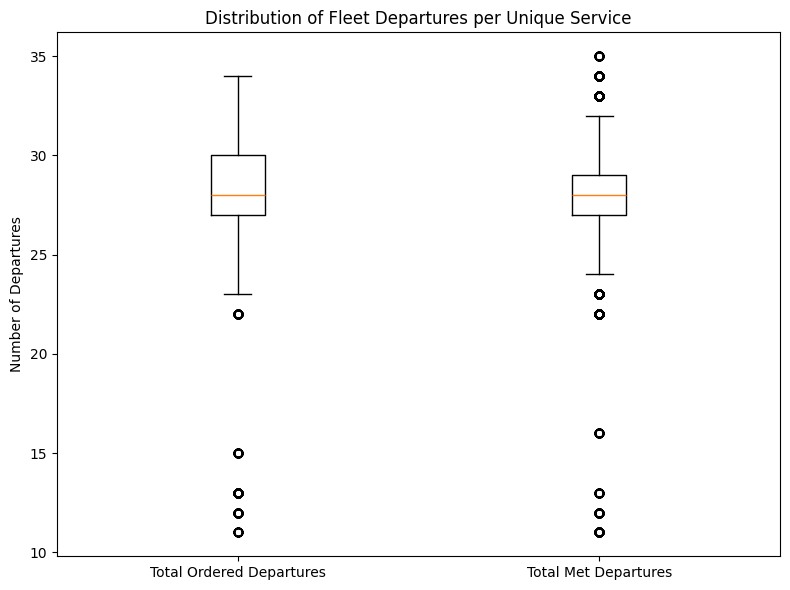

In [27]:
import matplotlib.pyplot as plt

fleet_per_service = df.drop_duplicates(subset='service_id')[['service_id', 'total_ordered_departures', 'total_met_departures']]

# Descriptive statistics
print("Descriptive statistics:")
print(fleet_per_service[['total_ordered_departures', 'total_met_departures']].describe())

# Boxplot
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [fleet_per_service['total_ordered_departures'].dropna(),
     fleet_per_service['total_met_departures'].dropna()],
    labels=['Total Ordered Departures', 'Total Met Departures']
)
ax.set_title('Distribution of Fleet Departures per Unique Service')
ax.set_ylabel('Number of Departures')
plt.tight_layout()
plt.show()

Descriptive statistics:
       Theoretical Rotation Time  Effective Rotation Time
count                   23420.00                 20297.00
mean                      118.70                   111.61
std                       122.73                    95.19
min                         1.00                     0.00
25%                        67.00                    61.32
50%                        91.00                    86.35
75%                       134.00                   128.68
max                      1439.00                  1439.73


/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_40857/3299995801.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


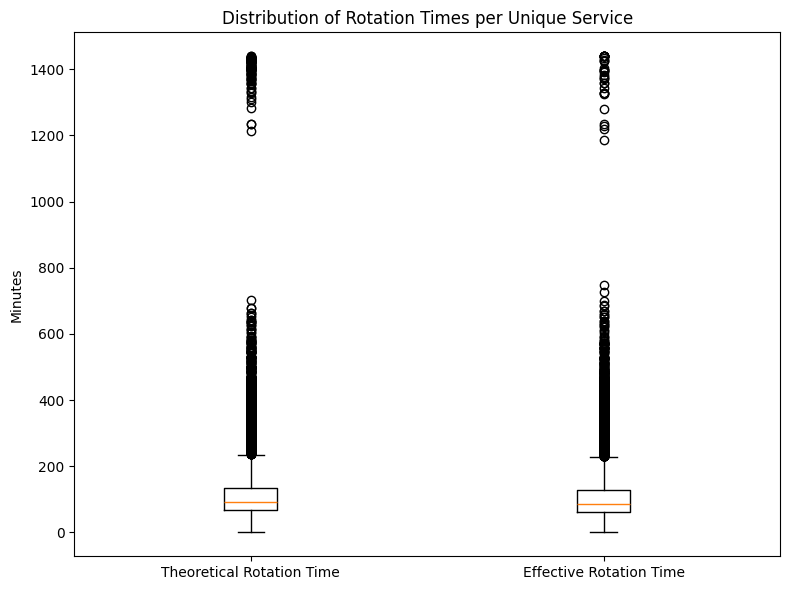

In [28]:
rotation_per_service = df.drop_duplicates(subset='service_id')[['service_id', 'Theoretical Rotation Time', 'Effective Rotation Time']]

# Descriptive statistics
print("Descriptive statistics:")
print(rotation_per_service[['Theoretical Rotation Time', 'Effective Rotation Time']].describe())

# Boxplot
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [rotation_per_service['Theoretical Rotation Time'].dropna(),
     rotation_per_service['Effective Rotation Time'].dropna()],
    labels=['Theoretical Rotation Time', 'Effective Rotation Time']
)
ax.set_title('Distribution of Rotation Times per Unique Service')
ax.set_ylabel('Minutes')
plt.tight_layout()
plt.show()

In [29]:
# One row per service_id (Aggregated Delay is identical within a service)
total_fleet_reliability = df.drop_duplicates(subset='service_id')[['service_id', 'total_fleet_reliability']]

mean_delay = total_fleet_reliability['total_fleet_reliability'].mean()

print(f"Unique service IDs: {len(delay_per_service)}")
print(f"Mean Total Fleet Reliability across all unique services: {mean_delay:.2f}")

Unique service IDs: 36511
Mean Total Fleet Reliability across all unique services: 0.98


Descriptive statistics:
       Departure Delay  Arrival Delay
count         27813.00       27875.00
mean             19.29          28.74
std              90.73          36.94
min           -1009.30       -1354.80
25%               0.10           1.80
50%               1.70          11.00
75%              25.90          60.00
max            7229.10         401.90


/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_40857/1191213923.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


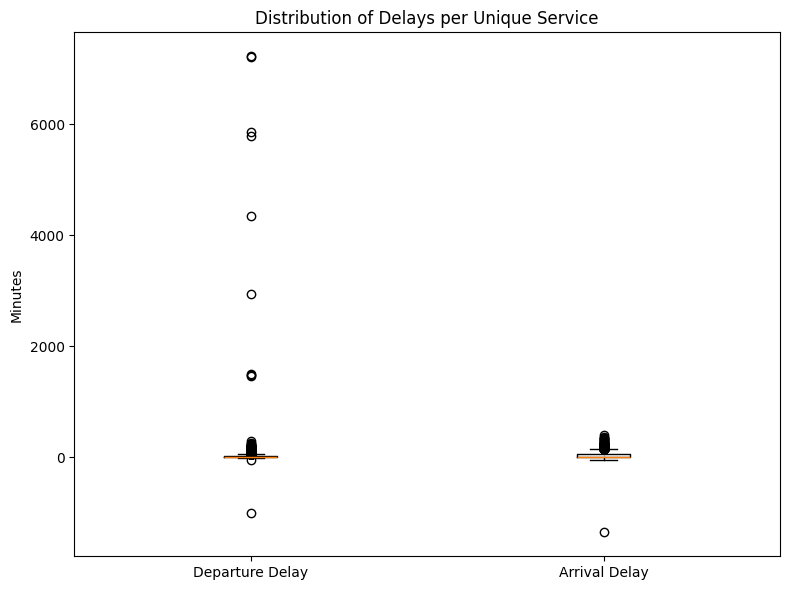

In [30]:
delay_cols_per_service = df.drop_duplicates(subset='service_id')[['service_id', 'Departure Delay', 'Arrival Delay']]

# Descriptive statistics
print("Descriptive statistics:")
print(delay_cols_per_service[['Departure Delay', 'Arrival Delay']].describe())

# Boxplot
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [delay_cols_per_service['Departure Delay'].dropna(),
     delay_cols_per_service['Arrival Delay'].dropna()],
    labels=['Departure Delay', 'Arrival Delay']
)
ax.set_title('Distribution of Delays per Unique Service')
ax.set_ylabel('Minutes')
plt.tight_layout()
plt.show()

Descriptive statistics:
       total_met_departures  total_ordered_departures
count              36282.00                  36282.00
mean                  27.84                     28.32
std                    2.55                      2.49
min                   11.00                     11.00
25%                   27.00                     27.00
50%                   28.00                     28.00
75%                   29.00                     30.00
max                   35.00                     34.00


/var/folders/fn/rg8vmcvx1bq3mq14q1fp3szr0000gn/T/ipykernel_40857/912787592.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


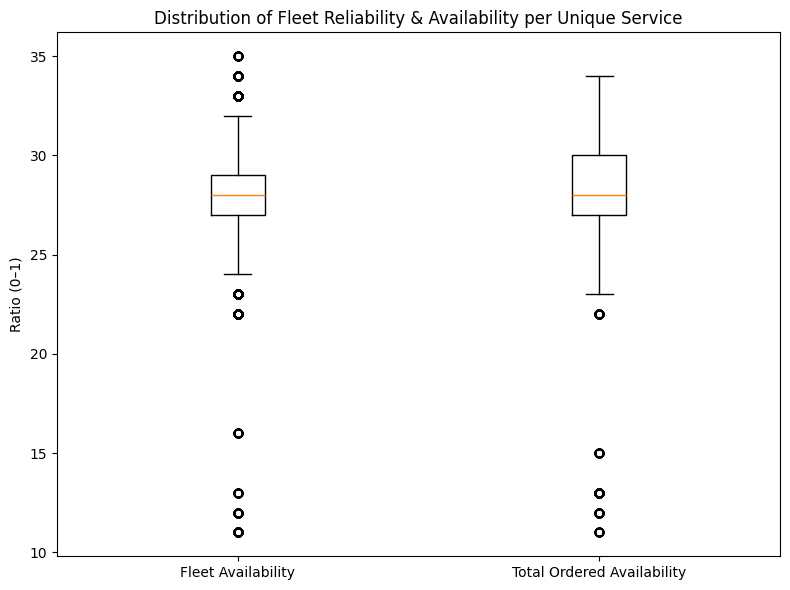

In [31]:
fleet_rel_per_service = df.drop_duplicates(subset='service_id')[['service_id', 'total_met_departures', 'total_ordered_departures']]

# Descriptive statistics
print("Descriptive statistics:")
print(fleet_rel_per_service[['total_met_departures', 'total_ordered_departures']].describe())

# Boxplot
fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [fleet_rel_per_service['total_met_departures'].dropna(),
     fleet_rel_per_service['total_ordered_departures'].dropna()],
    labels=['Fleet Availability', 'Total Ordered Availability']
)
ax.set_title('Distribution of Fleet Reliability & Availability per Unique Service')
ax.set_ylabel('Ratio (0–1)')
plt.tight_layout()
plt.show()